<a href="https://colab.research.google.com/github/Yuliia-Safonova/DTA-2026/blob/main/classmade/Pandas_tasks_beginners_DTA_28.05.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практичні завдання з pandas для початківців

**Мета:** Набути базових навичок роботи з бібліотекою pandas для аналізу табличних даних.

**Інструкції:**
- Виконуйте завдання послідовно — кожне наступне спирається на попередні.
- Після виконання кожного завдання напишіть короткий висновок у комірці `**Висновок:**`.
- Не змінюйте код у комірках з підготовкою даних.

**Набір даних:** Умовна таблиця продажів інтернет-магазину за 2023 рік.

---
## Підготовка: Генерація тестових даних

Запустіть цю комірку перед початком роботи. Не змінюйте код.

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

categories = ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт']
cities = ['Київ', 'Харків', 'Одеса', 'Дніпро', 'Львів']
payment_methods = ['Картка', 'Готівка', 'Онлайн']

df = pd.DataFrame({
    'order_id':        range(1001, 1001 + n),
    'date':            pd.date_range('2023-01-01', periods=n, freq='D')[:n],
    'category':        np.random.choice(categories, n),
    'product':         ['Товар_' + str(i) for i in np.random.randint(1, 51, n)],
    'city':            np.random.choice(cities, n),
    'quantity':        np.random.randint(1, 10, n),
    'price':           np.round(np.random.uniform(50, 5000, n), 2),
    'payment_method':  np.random.choice(payment_methods, n),
    'rating':          np.random.choice([1, 2, 3, 4, 5, np.nan], n, p=[0.05, 0.1, 0.15, 0.3, 0.3, 0.1]),
    'is_returned':     np.random.choice([True, False], n, p=[0.1, 0.9]),
})

# Додаємо кілька пропущених значень
df.loc[np.random.choice(df.index, 10, replace=False), 'city'] = np.nan
df.loc[np.random.choice(df.index, 5, replace=False), 'price'] = np.nan

# Розраховуємо загальну суму
df['total'] = df['quantity'] * df['price']

print('Дані успішно згенеровано. Рядків:', len(df))
print('Колонки:', list(df.columns))

Дані успішно згенеровано. Рядків: 200
Колонки: ['order_id', 'date', 'category', 'product', 'city', 'quantity', 'price', 'payment_method', 'rating', 'is_returned', 'total']


---
## Завдання 1 (Легке). Перший погляд на дані

Виведіть перші 10 рядків датафрейму `df` та отримайте загальну інформацію про нього (кількість рядків, колонок, типи даних) за допомогою методів `head()` та `info()`.

In [2]:
# Ваш код тут
df.head(10)

,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total
0,1001,2023-01-01,Продукти,Товар_34,Київ,1,963.38,Картка,5.0,False,963.38
1,1002,2023-01-02,Спорт,Товар_6,Львів,6,1086.28,Картка,4.0,False,6517.68
2,1003,2023-01-03,Книги,Товар_22,Дніпро,4,1883.84,Готівка,5.0,False,7535.36
3,1004,2023-01-04,Спорт,Товар_11,Дніпро,1,2448.39,Картка,5.0,False,2448.39
4,1005,2023-01-05,Спорт,Товар_48,Дніпро,7,3110.36,Онлайн,3.0,False,21772.52
5,1006,2023-01-06,Одяг,Товар_16,Львів,9,1876.12,Онлайн,NaN,False,16885.08
6,1007,2023-01-07,Книги,Товар_33,Дніпро,4,2339.55,Картка,4.0,False,9358.20
7,1008,2023-01-08,Книги,Товар_9,Львів,4,3749.98,Готівка,4.0,False,14999.92
8,1009,2023-01-09,Книги,Товар_6,Дніпро,6,231.58,Онлайн,4.0,False,1389.48
9,1010,2023-01-10,Спорт,Товар_16,Одеса,3,1299.56,Готівка,1.0,False,3898.68


In [3]:
df.iloc[4:7, 5:8] # перша пара - рядки 4-7, друга пара - стовпчики 5-8

,quantity,price,payment_method
4,7,3110.36,Онлайн
5,9,1876.12,Онлайн
6,4,2339.55,Картка


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        200 non-null    int64         
 1   date            200 non-null    datetime64[ns]
 2   category        200 non-null    object        
 3   product         200 non-null    object        
 4   city            190 non-null    object        
 5   quantity        200 non-null    int64         
 6   price           195 non-null    float64       
 7   payment_method  200 non-null    object        
 8   rating          177 non-null    float64       
 9   is_returned     200 non-null    bool          
 10  total           195 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 15.9+ KB


**Висновок:** *(Напишіть, скільки рядків і колонок у датафреймі, які типи даних зустрічаються, чи є пропущені значення)*

В цьому Датафреймі:  
- 200 рядків і 11 колонок  
- типи даних: булевий (1), числовий (дробовий тип - 3), цілі числа (2), об'єкти (4)  
- є пропущені значення

---
## Завдання 2 (Легке). Описова статистика

Використайте метод `describe()` для отримання описової статистики числових колонок. Окремо виведіть мінімум, максимум і середнє значення колонки `price`.

In [12]:
# Ваш код тут
df.describe().round(2)

,order_id,date,quantity,price,rating,total,rank
count,200.00,200,200.00,200.00,177.00,200.00,195.00
mean,1100.50,2023-04-10 12:00:00,4.70,2503.12,3.81,11680.13,98.00
min,1001.00,2023-01-01 00:00:00,1.00,139.65,1.00,149.35,1.00
25%,1050.75,2023-02-19 18:00:00,2.00,1298.77,3.00,3968.38,49.50
50%,1100.50,2023-04-10 12:00:00,5.00,2527.88,4.00,8754.22,98.00
75%,1150.25,2023-05-30 06:00:00,7.00,3674.69,5.00,17027.24,146.50
max,1200.00,2023-07-19 00:00:00,9.00,4950.30,5.00,44324.64,195.00
std,57.88,NaN,2.62,1362.86,1.17,9909.60,56.44


**Висновок:** *(Опишіть діапазон цін, середнє значення, чи є суттєвий розкид)*

Ціни коливаються від 139,65 до 4950,30.  
Середнє занчення - 2503,12.  
Ціни товарів мають суттєвий розкид.  
Стандартне відхилення становить 1362,86 грн, що дорівнює приблизно 54,4% від середньої ціни (2503,12 грн). При цьому середнє значення (2503,12 грн) майже збігається з медіаною (2527,88 грн), тому істотної асиметрії розподілу не спостерігається.

---
## Завдання 3 (Легке). Пропущені значення

Знайдіть кількість пропущених значень у кожній колонці за допомогою `isnull().sum()`. Визначте, який відсоток рядків має пропущені значення хоча б в одній колонці (`dropna()` та `len()`).

In [15]:
# Ваш код тут

missing = df.isnull().sum()
print("Кількість пропущених значень:")
print(missing)

# Загальна кількість рядків
total_rows = len(df)

# Кількість рядків без пропусків
clean_rows = len(df.dropna())

# Кількість рядків з пропусками
rows_with_missing = total_rows - clean_rows

# Відсоток
percent = rows_with_missing / total_rows * 100

print(f"\nРядків з пропущеними значеннями: {rows_with_missing}")
print(f"Відсоток таких рядків: {percent:.2f}%")

Кількість пропущених значень:
order_id           0
date               0
category           0
product            0
city               0
quantity           0
price              0
payment_method     0
rating            23
is_returned        0
total              0
rank               5
dtype: int64

Рядків з пропущеними значеннями: 28
Відсоток таких рядків: 14.00%


**Висновок:** *(У яких колонках є пропуски, наскільки це критично для аналізу)*

Пропущені значення є лише у колонках rating (23 пропуски) та rank (5 пропусків).

Пропуски в колонці rating означають, що частина покупців не залишила оцінку товару.

В інших колонках пропусків немає, тому дані про замовлення, ціни, кількість товарів та виручку є повними. Загалом кількість пропусків невелика, тому вони не є критичною проблемою для аналізу.

---
## Завдання 4 (Легке). Відбір колонок і рядків

Створіть новий датафрейм `df_subset`, що містить лише колонки `order_id`, `category`, `city`, `total`. Потім виведіть рядки з індексами від 10 до 20 включно за допомогою `.iloc[]`.

In [7]:
# Ваш код тут
df_subset = df[['order_id', 'category', 'city', 'total']]
df_subset.iloc[10:21, 1:] # додатково прибрали колонку order_id

,category,city,total
10,Продукти,Дніпро,21486.48
11,Книги,Львів,31368.89
12,Спорт,Харків,7748.40
13,Одяг,Дніпро,18787.72
14,Продукти,NaN,1741.50
15,Одяг,Одеса,4529.38
16,Продукти,Київ,10745.84
17,Спорт,Одеса,10001.84
18,Електроніка,Дніпро,12444.75
19,Продукти,Харків,13422.92


**Висновок:** *(Поясніть різницю між вибором колонок через список і через `iloc`)*

Вибір через список  - df[['category', 'city']] - здійснюється за назвами колонок, а через iloc - df.iloc[10:21, 1:] — за їхніми індексами.  
Вибір за назвами є більш наочним, а iloc зручний для вибору діапазонів рядків і колонок.

---
## Завдання 5 (Легке). Фільтрація даних

Відфільтруйте датафрейм і отримайте:
1. Всі замовлення з категорії `'Електроніка'`.
2. Всі замовлення, де `price` перевищує 2000.
3. Поверненi замовлення (`is_returned == True`) з міста `'Київ'`.

Виведіть кількість рядків для кожного фільтру.

In [8]:
# Ваш код тут
df[df['category'] == 'Електроніка']
df[df['price'] > 2000]
df[(df['is_returned'] == True) & (df['city'] == 'Київ')]

print(len(df[df['category'] == 'Електроніка']) / df.shape[0]*100)

print(df[(df['is_returned'] == True) & (df['city'] == 'Київ')].shape[0] / df[df['is_returned'] == True].shape[0]*100)
print(df[(df['is_returned'] == True) & (df['city'] == 'Київ')].shape[0] / df[df['city'] == 'Київ'].shape[0]*100)

print(df['city'].unique())

returned_by_city = df.groupby('city').agg(count_ = ('order_id', 'count'), is_ret = ('is_returned', 'sum'))
returned_by_city['percent'] = (returned_by_city['is_ret'] / returned_by_city['count_'] * 100).round(2)
display(returned_by_city.sort_values(by='percent'))


21.5
28.000000000000004
18.91891891891892
['Київ' 'Львів' 'Дніпро' 'Одеса' 'Харків' nan]


,count_,is_ret,percent
city,,,
Дніпро,38,2,5.26
Харків,39,3,7.69
Львів,46,5,10.87
Київ,37,7,18.92
Одеса,30,7,23.33


**Висновок:** *(Яка частка замовлень відповідає кожному критерію? Що можна сказати про повернення з Києва?)*

---
## Завдання 6 (Середнє). Сортування та ранжування

1. Відсортуйте датафрейм за колонкою `total` у спадному порядку та виведіть топ-10 найбільших замовлень.
2. Додайте нову колонку `rank`, що містить порядковий номер замовлення за розміром суми (від найбільшого до найменшого) за допомогою `.rank()`.

In [9]:
# Ваш код тут
df['rank'] = df['total'].rank(ascending=False, method = 'min')
df.sort_values('total', ascending=False).head(10)

,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
190,1191,2023-07-10,Одяг,Товар_22,Київ,9,4924.96,Готівка,4.0,True,44324.64,1.0
58,1059,2023-02-28,Продукти,Товар_33,Харків,9,4848.88,Картка,5.0,False,43639.92,2.0
186,1187,2023-07-06,Спорт,Товар_34,Київ,9,4675.12,Готівка,5.0,False,42076.08,3.0
55,1056,2023-02-25,Електроніка,Товар_3,Дніпро,8,4912.77,Картка,5.0,False,39302.16,4.0
169,1170,2023-06-19,Продукти,Товар_50,Київ,8,4739.05,Готівка,5.0,False,37912.40,5.0
191,1192,2023-07-11,Спорт,Товар_25,Харків,9,4202.55,Готівка,4.0,True,37822.95,6.0
193,1194,2023-07-13,Одяг,Товар_22,NaN,8,4608.17,Картка,4.0,False,36865.36,7.0
51,1052,2023-02-21,Продукти,Товар_35,Дніпро,8,4488.99,Онлайн,4.0,False,35911.92,8.0
25,1026,2023-01-26,Книги,Товар_18,Дніпро,8,4458.11,Картка,3.0,False,35664.88,9.0
143,1144,2023-05-24,Продукти,Товар_31,Київ,9,3732.53,Готівка,5.0,False,33592.77,10.0


**Висновок:** *(Яка максимальна сума замовлення? З яких категорій найбільші замовлення?)*

---
## Завдання 7 (Середнє). Групування та агрегація

За допомогою `groupby()` розрахуйте для кожної категорії товарів:
- загальний обсяг продажів (сума `total`),
- кількість замовлень,
- середню ціну (`price`).

Відсортуйте результат за загальним обсягом продажів.

,total
category,
Електроніка,428129.79
Книги,380844.39
Одяг,474135.61
Продукти,583761.68
Спорт,400802.56


,total
category,
Електроніка,43
Книги,36
Одяг,34
Продукти,47
Спорт,35


,price
category,
Електроніка,2334.470698
Книги,2491.881944
Одяг,2707.906176
Продукти,2513.979787
Спорт,2494.205143


<Axes: xlabel='category'>

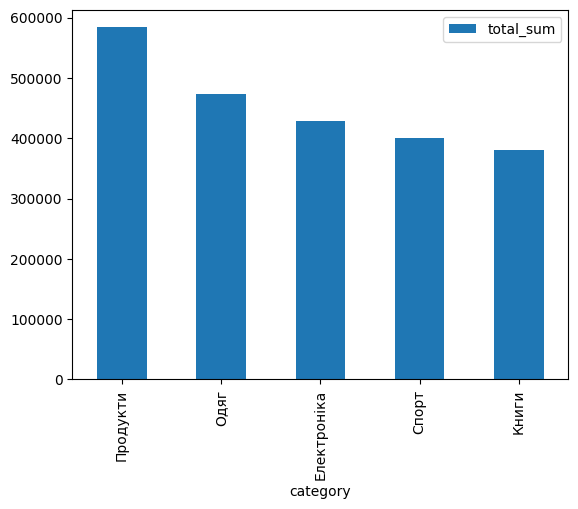

In [10]:
# Ваш код тут
display(df.groupby('category')['total'].sum())
display(df.groupby('category')['total'].count())
display(df.groupby('category')['price'].mean())

display(df.groupby('category').agg(total_sum = ('total', 'sum'),
                                   total_count = ('total', 'count'),
                                   price_mean = ('price','mean')).sort_values('total_sum', ascending=False).plot(kind = 'bar', y = 'total_sum'))

# display(df.groupby('category').agg({'total':'sum',
#                                     'total':'count',
#                                     'price':'mean'}))


**Висновок:** *(Яка категорія приносить найбільший дохід? Чи збігається це з кількістю замовлень?)*

---
## Завдання 8 (Середнє). Обробка пропущених значень

1. Заповніть пропущені значення в колонці `price` медіаною цін відповідної категорії (використайте `groupby().transform('median')`).
2. Заповніть пропущені значення в колонці `city` рядком `'Невідомо'`.
3. Пропущені значення в `rating` залиште без змін — поясніть чому у висновку.

Перевірте, що пропусків у `price` та `city` більше немає.

In [19]:
# Ваш код тут
display(df[df['price'].isna()])
median_price = df.groupby('category')['price'].transform('median')
display(median_price)
df['price'] = df['price'].fillna(median_price)
df['total'] = df['total'].fillna(df['price']*df['quantity'])
df['city'] = df['city'].fillna('Невідомо')
display(df.iloc[66:73])
display(df[df['rating'].isna()].sort_values('product'))
print(df[['price', 'city']].isna().sum())

,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank


,price
0,2740.590
1,2448.390
2,2461.385
3,2448.390
4,2448.390
...,...
195,2461.385
196,2461.385
197,2025.060
198,2448.390


,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
66,1067,2023-03-08,Одяг,Товар_20,Одеса,3,2619.055,Готівка,5.0,False,7857.165,NaN
67,1068,2023-03-09,Одяг,Товар_35,Харків,6,1435.900,Готівка,NaN,False,8615.400,100.0
68,1069,2023-03-10,Продукти,Товар_48,Київ,2,3858.990,Готівка,3.0,True,7717.980,108.0
69,1070,2023-03-11,Продукти,Товар_25,Львів,3,975.870,Картка,4.0,False,2927.610,163.0
70,1071,2023-03-12,Електроніка,Товар_35,Львів,5,1652.210,Готівка,NaN,False,8261.050,103.0
71,1072,2023-03-13,Спорт,Товар_25,Дніпро,9,2155.910,Готівка,1.0,False,19403.190,35.0
72,1073,2023-03-14,Спорт,Товар_29,Харків,2,2448.390,Готівка,5.0,False,4896.780,NaN


,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
5,1006,2023-01-06,Одяг,Товар_16,Львів,9,1876.12,Онлайн,NaN,False,16885.08,50.0
140,1141,2023-05-21,Електроніка,Товар_18,Київ,3,800.79,Онлайн,NaN,True,2402.37,172.0
75,1076,2023-03-17,Одяг,Товар_18,Одеса,5,3072.57,Картка,NaN,False,15362.85,59.0
153,1154,2023-06-03,Електроніка,Товар_2,Дніпро,1,2016.57,Готівка,NaN,False,2016.57,177.0
156,1157,2023-06-06,Продукти,Товар_2,Дніпро,8,1184.79,Онлайн,NaN,False,9478.32,87.0
76,1077,2023-03-18,Електроніка,Товар_2,Невідомо,7,1478.72,Картка,NaN,False,10351.04,83.0
106,1107,2023-04-17,Книги,Товар_21,Харків,1,741.87,Онлайн,NaN,False,741.87,191.0
104,1105,2023-04-15,Електроніка,Товар_27,Львів,5,2893.64,Онлайн,NaN,False,14468.20,67.0
136,1137,2023-05-17,Продукти,Товар_32,Львів,6,3119.36,Онлайн,NaN,False,18716.16,38.0
48,1049,2023-02-18,Одяг,Товар_32,Київ,9,973.51,Готівка,NaN,False,8761.59,97.0


price    0
city     0
dtype: int64


**Висновок:** *(Чому медіана краща за середнє для заповнення цін? Чому пропуски в rating можна залишити?)*

Медіана більш стійка до викидів. Медіана дає більш реалістичну заміну пропущених цін, особливо коли є нерівномірні або екстремальні значення.  
Пропуски в rating можна залишити, тому що NaN у rating — це не помилка даних, а відсутність відгуку.

---
## Завдання 9 (Середнє). Додавання обчислюваних колонок

Додайте до датафрейму нові колонки:
1. `month` — місяць замовлення (з колонки `date`).
2. `price_category` — категорія ціни: `'Низька'` (до 500), `'Середня'` (500–2000), `'Висока'` (понад 2000). Використайте `pd.cut()` або `np.select()`.
3. `discount_total` — сума зі знижкою 15%.

In [ ]:
# Ваш код тут
import numpy as np

df['month'] = df['date'].dt.month
df['price_category'] = pd.cut(df['price'], bins = [0, 500, 2000, float('inf')], labels = ['Низька', 'Середня', 'Висока'])
# df['price_category2'] = np.select([df['price'] < 500, df['price'] > 2000], ['Низька', 'Середня', 'Висока'] )

df['price_category'] = np.select([df['price'] <= 500, (df['price'] > 500) & (df['price'] <= 2000), df['price'] > 2000], ['Низька', 'Середня', 'Висока'], default='Невідомо')

df['discount_total'] = (df['total']*0.85).round(2)

x = df.groupby('price_category').agg(total_sum = ('total', 'sum'),
                                         count_ = ('order_id', 'count')).plot(kind='pie', y = 'total_sum')

display(df.groupby('price_category').agg(total_sum = ('total', 'sum'),
                                         count_ = ('order_id', 'count')))

**Висновок:** *(Який розподіл цінових категорій? Як метод pd.cut спрощує категоризацію?)*

Метод pd.cut значно спрощує категоризацію, оскільки автоматично ділить числові дані на задані інтервали (bins). Завдяки цьому легше аналізувати дані та порівнювати різні цінові сегменти.

---
## Завдання 10 (Середнє). Зведена таблиця (pivot table)

Побудуйте зведену таблицю за допомогою `pd.pivot_table()`, де:
- рядки — `city`,
- колонки — `category`,
- значення — сума `total`,
- агрегація — `sum`.

Додайте підсумки по рядках і колонках (`margins=True`).

In [20]:
# Ваш код тут
pd.pivot_table(
    df,
    index = 'city',
    columns = 'category',
    values = 'total',
    aggfunc = 'sum',
    margins = True
).round(2).sort_values('All', ascending=False)

category,Електроніка,Книги,Одяг,Продукти,Спорт,All
city,,,,,,
All,428129.79,398074.08,481992.78,622129.94,405699.34,2336025.93
Харків,44068.06,15669.18,135537.23,199766.70,105100.00,500141.17
Київ,58713.88,87339.03,103754.43,118283.10,113742.95,481833.39
Львів,154285.60,126188.88,74340.69,55768.80,43155.08,453739.06
Дніпро,65438.16,116118.97,31179.87,147336.56,72244.38,432317.94
Одеса,84611.65,26773.57,90218.24,60466.75,65539.34,327609.56
Невідомо,21012.44,25984.45,46962.31,40508.03,5917.59,140384.82


**Висновок:** *(Яке місто і яка категорія дають найбільший сумарний дохід? Що показують margins?)*

Найбільший сумарний дохід серед міст приносить Харків — 500 141,17 грн. Серед категорій найбільшу виручку генерує категорія «Продукти» — 622 129,94 грн.

Параметр margins=True додає підсумкові значення в рядок і стовпець All. Рядок All показує загальну виручку по кожній категорії незалежно від міста, а стовпець All — загальну виручку по кожному місту незалежно від категорії.

---
## Завдання 11 (Середнє). Підрахунок унікальних значень і частот

1. Підрахуйте кількість унікальних товарів (`product`) у кожній категорії.
2. Виведіть топ-5 найпопулярніших товарів за кількістю замовлень за допомогою `value_counts()`.
3. Визначте частку кожного способу оплати у відсотках (`normalize=True`).

In [25]:
# Ваш код тут

# Кількість унікальних товарів у кожній категорії
display(df.groupby('category')['product'].nunique())

# Топ-5 найпопулярніших товарів за кількістю замовлень
display(df['product'].value_counts().head(5))

# Частка кожного способу оплати у відсотках
display((df['payment_method'].value_counts(normalize=True) * 100).round(2))

,product
category,
Електроніка,32
Книги,25
Одяг,27
Продукти,30
Спорт,25


,count
product,
Товар_33,11
Товар_48,9
Товар_35,9
Товар_22,7
Товар_20,6


,proportion
payment_method,
Готівка,34.0
Онлайн,33.5
Картка,32.5


**Висновок:** *(Який спосіб оплати найпопулярніший? Чи рівномірний розподіл між способами?)*

У кожній категорії представлена різна кількість унікальних товарів.  
Найпопулярніші товари мають найбільшу кількість замовлень.  
Аналіз способів оплати показує, що найпопулярнішим способом є оплата готівкою.

---
## Завдання 12 (Середнє). Аналіз повернень

Розрахуйте рівень повернень (частку повернених замовлень) для кожної категорії та кожного міста. Визначте:
- категорію з найвищим рівнем повернень,
- місто з найнижчим рівнем повернень.

Підказка: використайте `groupby()['is_returned'].mean()`.

In [33]:
# Ваш код тут

# Рівень повернень по категоріях
returns_by_category = df.groupby('category')['is_returned'].mean().round(2)
display(returns_by_category)

# Категорія з найвищим рівнем повернень
max_category = returns_by_category.idxmax()
max_rate = returns_by_category.max()
print(f"\nКатегорія з найвищим рівнем повернень: {max_category} - {max_rate}")

# Рівень повернень по містах
returns_by_city = df.groupby('city')['is_returned'].mean().round(2)
display(returns_by_city)

# Місто з найнижчим рівнем повернень
min_city = returns_by_city.idxmin()
min_rate = returns_by_city.min()
print(f"\nМісто з найнижчим рівнем повернень: {min_city} - {min_rate}")

,is_returned
category,
Електроніка,0.16
Книги,0.14
Одяг,0.17
Продукти,0.06
Спорт,0.11



Категорія з найвищим рівнем повернень: Одяг - 0.17


,is_returned
city,
Дніпро,0.05
Київ,0.19
Львів,0.11
Невідомо,0.10
Одеса,0.23
Харків,0.08



Місто з найнижчим рівнем повернень: Дніпро - 0.05


**Висновок:** *(Яка категорія найчастіше повертається? Про що це може свідчити?)*

Найвищий рівень повернень спостерігається в категорії "Одяг", що може свідчити про специфіку цієї групи товарів (наприклад, примірку товарів).

---
## Завдання 13 (Підвищена складність). Часовий аналіз

1. Встановіть колонку `date` як індекс датафрейму.
2. Розрахуйте щомісячний обсяг продажів (ресемплінг `resample('ME')` або `resample('M')`, sum по `total`).
3. Знайдіть найкращий і найгірший місяці за продажами.
4. Поверніть звичайний числовий індекс (`reset_index()`).

In [47]:
# Ваш код тут
# df['month'] = df['date'].dt.strftime(' %B %Y')
# df.resample('ME', on = 'date')['total'].sum().plot(kind='bar', )

# Встановіть колонку date як індекс датафрейму
# df = df.set_index('date')
# display(df.head())

# Розрахуйте щомісячний обсяг продажів
monthly_sales = df['total'].resample('ME').sum()
display(monthly_sales)

# Знайти найкращий місяць
best_month = monthly_sales.idxmax()
best_sales = monthly_sales.max()

print(f"\nНайкращий місяць за продажами - {best_month.strftime('%B %Y')}. Сума продажів = {best_sales} грн.")

# Знайти найгірший місяць
worst_month = monthly_sales.idxmin()
worst_sales = monthly_sales.min()

print(f"\nНайгірший місяць за продажами - {worst_month.strftime('%B %Y')}. Сума продажів = {worst_sales} грн.")

# Поверніть звичайний числовий індекс (reset_index())
df = df.reset_index()


,total
date,
2023-01-31,351659.990
2023-02-28,354807.150
2023-03-31,305283.785
2023-04-30,322315.225
2023-05-31,335619.620
2023-06-30,386464.610
2023-07-31,279875.550



Найкращий місяць за продажами - June 2023. Сума продажів = 386464.61 грн.

Найгірший місяць за продажами - July 2023. Сума продажів = 279875.55 грн.


**Висновок:** *(Який місяць виявився найуспішнішим? Чи є сезонність у даних?)*

Найуспішнішим виявився червень 2023 з найбільшим обсягом виручки. Найнижчі продажі спостерігалися у липні 2023. Для виявлення сезонних закономірностей потрібні дані щонайменше за декілька років.

---
## Завдання 14 (Підвищена складність). Накопичувальні показники

1. Відсортуйте датафрейм за датою.
2. Додайте колонку `cumulative_total` — накопичувальний обсяг продажів з початку року (`cumsum()`).
3. Визначте, в який день було досягнуто 50% від загального річного обсягу продажів.

In [56]:
# Ваш код тут
# Відсортуйте датафрейм за датою.
df = df.sort_values('date')

# Додайте колонку cumulative_total — накопичувальний обсяг продажів з початку року (cumsum()).
df['cumulative_total'] = df['total'].cumsum()

# Визначте, в який день було досягнуто 50% від загального річного обсягу продажів.
total_sum = df['total'].sum()
half_point = total_sum * 0.5
day_50 = df[df['cumulative_total'] >= half_point].iloc[0]
print("Дата досягнення 50% продажів:", day_50['date'].date())

Дата досягнення 50% продажів: 2023-04-14


**Висновок:** *(Коли приблизно була зароблена половина річного доходу? Що це означає для бізнесу?)*

Половина річного доходу була зароблена приблизно до 2023-04-14. Це може свідчити про сильний старт продажів або сезонний попит на початку року.

---
## Завдання 15 (Підвищена складність). apply() та lambda

1. Використайте `apply()` з lambda-функцією для створення колонки `total_with_tax`, де ПДВ становить 20%, але лише для замовлень на суму понад 1000 (решта — без змін).
2. Напишіть функцію `classify_rating(r)`, що повертає `'Поганий'` (1–2), `'Нейтральний'` (3), `'Хороший'` (4–5), `'Без оцінки'` (NaN). Застосуйте її до колонки `rating`.

In [ ]:
# Ваш код тут


**Висновок:** *(Яка частка замовлень має хороший рейтинг? Коли apply кращий за vectorized-операції?)*

---
## Завдання 16 (Підвищена складність). Злиття датафреймів (merge)

Створіть додатковий датафрейм `df_discounts` з колонками `category` та `discount_pct` (різні знижки для кожної категорії). Об'єднайте його з основним датафреймом за допомогою `pd.merge()` та розрахуйте `final_total` — суму після застосування відповідної знижки.

```python
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})
```

In [ ]:
df_discounts = pd.DataFrame({
    'category':     ['Електроніка', 'Одяг', 'Книги', 'Продукти', 'Спорт'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})

# Ваш код тут


**Висновок:** *(Яка категорія отримала найбільшу сумарну знижку? Коли варто використовувати merge замість map?)*

---
## Завдання 17 (Підвищена складність). Групові трансформації

1. Додайте колонку `city_avg_total` — середня сума замовлення по місту (для кожного рядка підставте середнє по його місту), використайте `groupby().transform('mean')`.
2. Додайте колонку `above_city_avg` — булева колонка, що показує, чи перевищує замовлення середнє по місту.
3. Підрахуйте частку таких замовлень для кожного міста.

In [ ]:
# Ваш код тут


**Висновок:** *(Чим transform відрізняється від звичайного groupby? У якому місті найбільша частка великих замовлень?)*

---
## Завдання 18 (Складне). Ковзне середнє та аномалії

1. Згрупуйте дані за місяцем та розрахуйте щоденну виручку.
2. Розрахуйте 7-денне ковзне середнє виручки (`rolling(7).mean()`).
3. Визначте дні-аномалії: дні, коли виручка відхилилася від ковзного середнього більш ніж на 2 стандартних відхилення.

In [ ]:
# Ваш код тут


**Висновок:** *(Скільки аномальних днів виявлено? Що може бути причиною різких відхилень виручки?)*

---
## Завдання 19 (Складне). Когортний аналіз

Виконайте спрощений когортний аналіз за місяцем першого замовлення:
1. Для кожного товару (`product`) знайдіть місяць першого продажу — це його «когорта».
2. Об'єднайте цю інформацію з основним датафреймом.
3. Побудуйте зведену таблицю: когорта (місяць першого продажу) проти місяця замовлення, значення — кількість замовлень.

Підказка: використайте `groupby('product')['date'].transform('min')` та `dt.to_period('M')`.

In [ ]:
# Ваш код тут


**Висновок:** *(Що показує когортна таблиця? Чи продовжують товари з першої когорти продаватися в наступних місяцях?)*

---
## Завдання 20 (Складне). Підсумковий звіт

Сформуйте підсумковий звіт у вигляді одного датафрейму `summary_report`, що містить для кожної категорії:
- загальний дохід (`total_revenue`),
- кількість замовлень (`order_count`),
- середній чек (`avg_order_value`),
- частку доходу від загального (`revenue_share_pct`),
- рівень повернень у відсотках (`return_rate_pct`),
- середній рейтинг без NaN (`avg_rating`).

Відсортуйте за `total_revenue` спадно. Збережіть результат у файл `summary_report.csv`.

In [ ]:
# Ваш код тут


**Висновок:** *(Яка категорія є лідером за доходом? Чи є зв'язок між рейтингом та рівнем повернень? Які рекомендації можна дати бізнесу на основі цього звіту?)*

---
## Загальні підсумки

Після виконання всіх завдань дайте відповідь на такі питання:

1. Які методи pandas виявилися для вас найбільш корисними?
2. Які труднощі виникли під час роботи з пропущеними значеннями?
3. Що можна додати до аналізу, щоб зробити його більш повним?

*(Ваші відповіді тут)*